In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import datetime

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes



In [2]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
returns = returns.apply(pd.to_numeric, errors="coerce")
returns = returns.dropna(axis=1, how="any")

features = np.load("../../data/features.npy")

# checks básicos
print(returns.shape)   # (T, N)
print(features.shape)  # (N, T, P)


(790, 0)
(169, 788, 1)


In [3]:


prices = pd.read_parquet("../../data/prices.parquet")
volumes = pd.read_parquet("../../data/volumes.parquet")

print("prices range:", prices.index.min(), prices.index.max(), "shape:", prices.shape)
print("volumes range:", volumes.index.min(), volumes.index.max(), "shape:", volumes.shape)

prices range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)
volumes range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)


In [5]:

print("features.npy mtime:", datetime.datetime.fromtimestamp(os.path.getmtime("../../data/features.npy")))
print("returns.csv mtime:", datetime.datetime.fromtimestamp(os.path.getmtime("../../data/returns.csv")))
features = np.load("../../data/features.npy")
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
print("features shape:", features.shape)
print("returns start:", returns.index.min())

features.npy mtime: 2026-01-16 02:46:12.128182
returns.csv mtime: 2026-01-16 02:46:12.101782
features shape: (169, 788, 1)
returns start: 2021-11-11


In [6]:
returns = returns.apply(pd.to_numeric, errors="coerce")
returns = returns.dropna(axis=0, how="any")
returns = returns.dropna(axis=1, how="all")

# drop near-constant assets (avoid NaN/unstable correlations)
std = returns.std(axis=0)
returns = returns.loc[:, std > 1e-8]
print("returns shape after clean:", returns.shape)
if returns.shape[1] < 2:
    raise ValueError("Not enough assets after cleaning returns. Re-check returns.csv generation.")
R = returns.values
corr = np.corrcoef(R, rowvar=False)

returns shape after clean: (788, 169)


In [7]:
alpha = 2.0  # NO se quita

# Ventana temporal coherente (≈ 3 años de trading days)
T_window = 756
window = slice(-T_window, None)

rho_list = []
for i in range(features.shape[0]):
    rho_i = average_density_matrix(
        features[i][window],  # (T_window, P)
        alpha
    )
    rho_list.append(rho_i)

D_quantum = compute_distance_matrix(rho_list)

In [9]:
# Correlation → distance
dist_classical = np.sqrt(0.5 * (1 - corr))

# Higiene numérica (obligatoria)
dist_classical = 0.5 * (dist_classical + dist_classical.T)
np.fill_diagonal(dist_classical, 0.0)
dist_classical = np.nan_to_num(dist_classical)

# Clustering
link_classical = linkage(squareform(dist_classical), method="single")
order_classical = leaves_list(link_classical)

corr_classical = corr[np.ix_(order_classical, order_classical)]



In [10]:
# usar exactamente el ordering del repo
order_quantum = quantum_ordering(D_quantum)
D_quantum_ordered = D_quantum[np.ix_(order_quantum, order_quantum)]


corr_quantum = corr[np.ix_(order_quantum, order_quantum)]

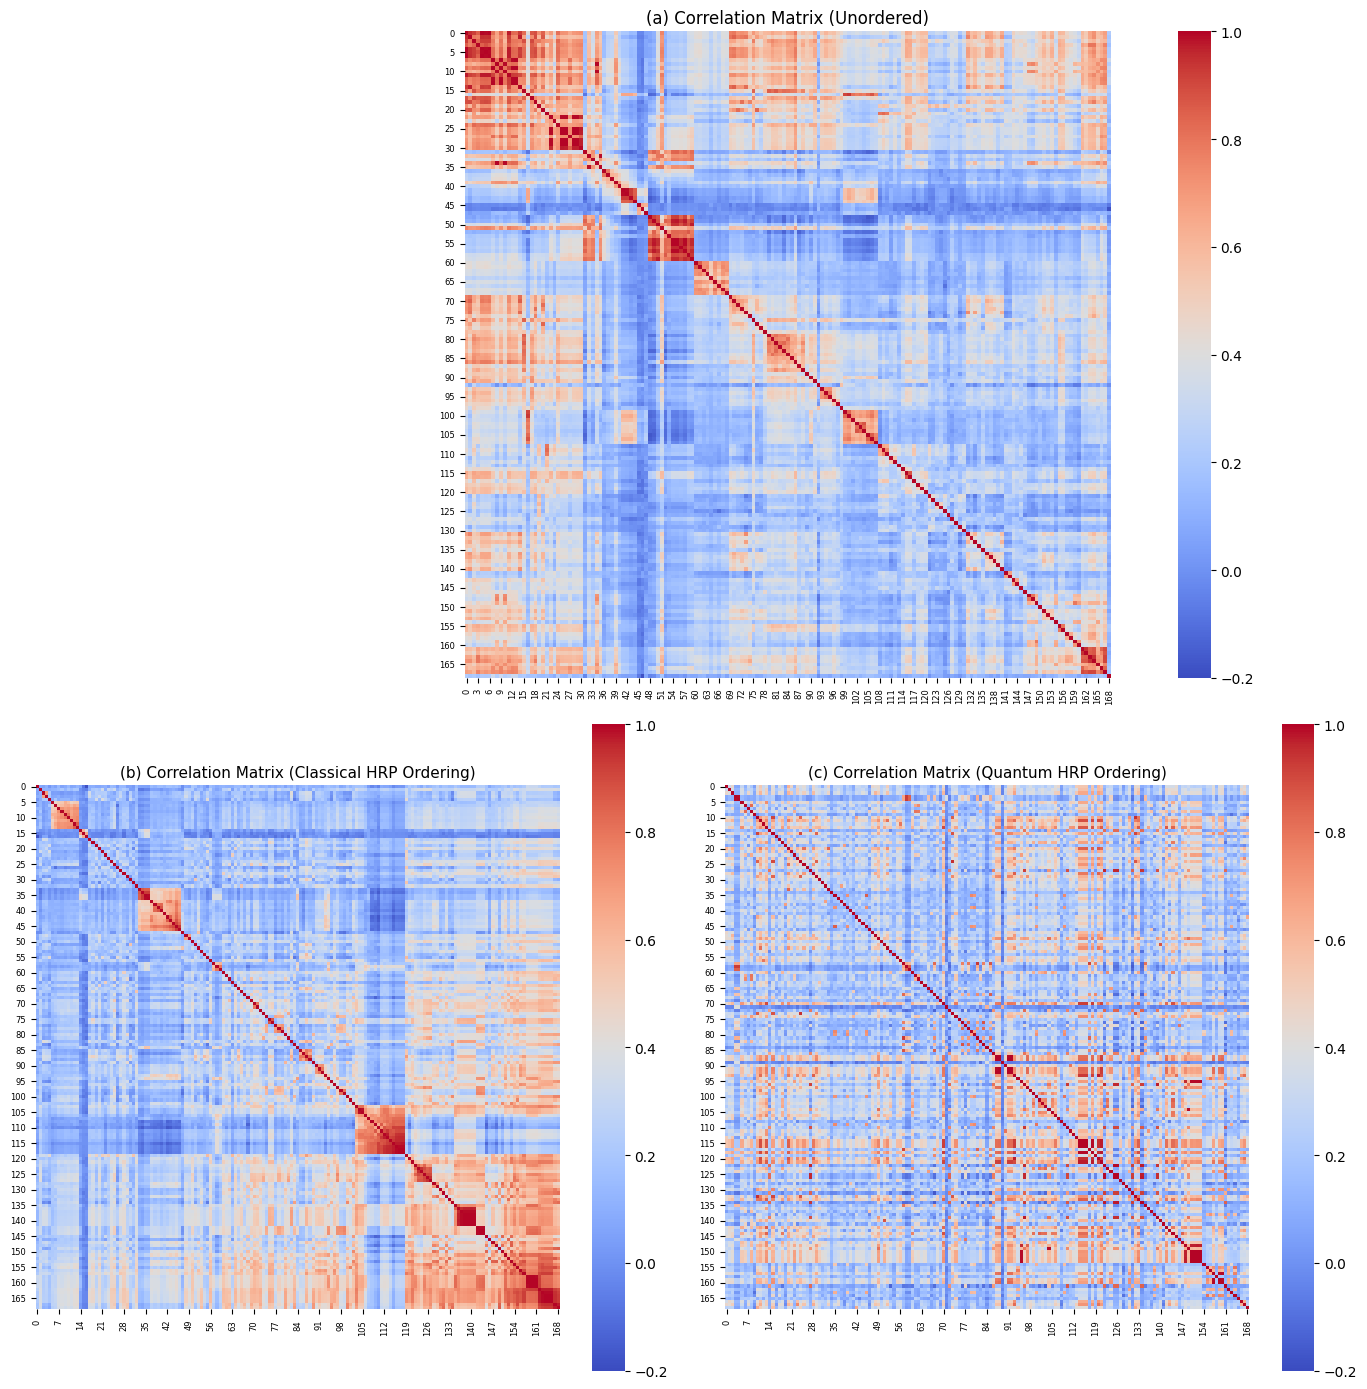

In [15]:
out_dir = os.path.abspath("../../latex/img")
os.makedirs(out_dir, exist_ok=True)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Unordered ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Correlation Matrix (Unordered)", fontsize=12)
ax0.tick_params(labelsize=6)

# ---------- (b) Classical HRP ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Correlation Matrix (Classical HRP Ordering)", fontsize=11)
ax1.tick_params(labelsize=6)

# ---------- (c) Quantum HRP ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Correlation Matrix (Quantum HRP Ordering)", fontsize=11)
ax2.tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.jpg"), dpi=300, bbox_inches="tight")
plt.show()

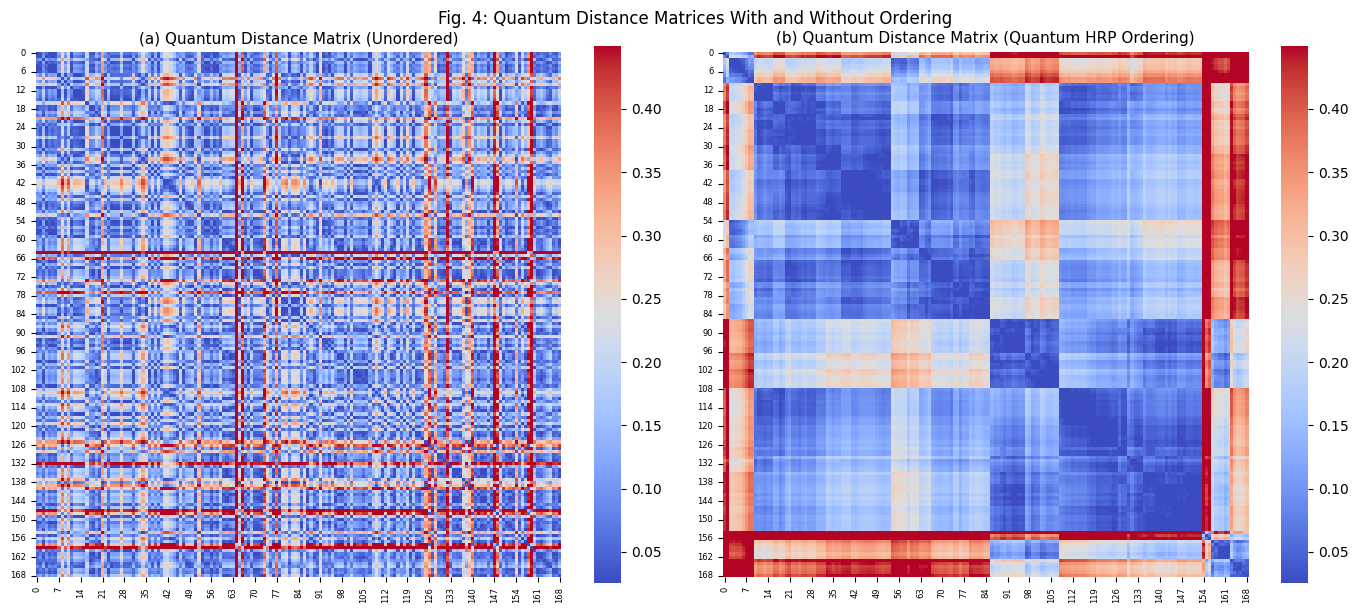

In [16]:
# Reordered quantum distance matrix
D_quantum_ordered = D_quantum[np.ix_(order_quantum, order_quantum)]

# Use robust scaling to enhance contrast
vmin_q = float(np.percentile(D_quantum, 5))
vmax_q = float(np.percentile(D_quantum, 95))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- (a) Unordered ----------
sns.heatmap(
    D_quantum,
    cmap="coolwarm",
    vmin=vmin_q,
    vmax=vmax_q,
    square=True,
    cbar=True,
    ax=axes[0]
 )
axes[0].set_title("(a) Quantum Distance Matrix (Unordered)", fontsize=11)
axes[0].tick_params(labelsize=6)

# ---------- (b) Ordered ----------
sns.heatmap(
    D_quantum_ordered,
    cmap="coolwarm",
    vmin=vmin_q,
    vmax=vmax_q,
    square=True,
    cbar=True,
    ax=axes[1]
 )
axes[1].set_title("(b) Quantum Distance Matrix (Quantum HRP Ordering)", fontsize=11)
axes[1].tick_params(labelsize=6)

plt.suptitle(
    "Fig. 4: Quantum Distance Matrices With and Without Ordering",
    fontsize=12,
    y=0.98
)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-quantum-distance.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-quantum-distance.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-quantum-distance.jpg"), dpi=300, bbox_inches="tight")
plt.show()